# ALY6020 Final Exam Code




In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 120

In [16]:
df_raw = pd.read_csv("car_insurance (1) (1).csv")
df_raw.head()

,ID,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,0-9y,high school,upper class,0.629027,1,0,1,10238,12000.0,sedan,0,0,0,0
1,750365,16-25,male,0-9y,none,poverty,0.357757,0,0,0,10238,16000.0,sedan,0,0,0,1
2,199901,16-25,female,0-9y,high school,working class,0.493146,1,0,0,10238,11000.0,sedan,0,0,0,0
3,478866,16-25,male,0-9y,university,working class,0.206013,1,0,1,32765,11000.0,sedan,0,0,0,0
4,731664,26-39,male,10-19y,none,working class,0.388366,1,0,0,32765,12000.0,sedan,2,0,1,1


## Question 6

In [17]:
field_review = []
for col in df_raw.columns:
    s = df_raw[col]
    field_review.append({
        "Variable": col,
        "dtype": str(s.dtype),
        "Missing_Count": int(s.isna().sum()),
        "Missing_Pct": round(s.isna().mean() * 100, 2),
        "Unique_Values": int(s.nunique(dropna=True))
    })

field_review_df = pd.DataFrame(field_review)
field_review_df

,Variable,dtype,Missing_Count,Missing_Pct,Unique_Values
0,ID,int64,0,0.00,10000
1,AGE,object,0,0.00,4
2,GENDER,object,0,0.00,2
3,DRIVING_EXPERIENCE,object,0,0.00,4
4,EDUCATION,object,0,0.00,3
5,INCOME,object,0,0.00,4
6,CREDIT_SCORE,float64,982,9.82,9018
7,VEHICLE_OWNERSHIP,int64,0,0.00,2
8,MARRIED,int64,0,0.00,2
9,CHILDREN,int64,0,0.00,2


### distribution and outlier checks

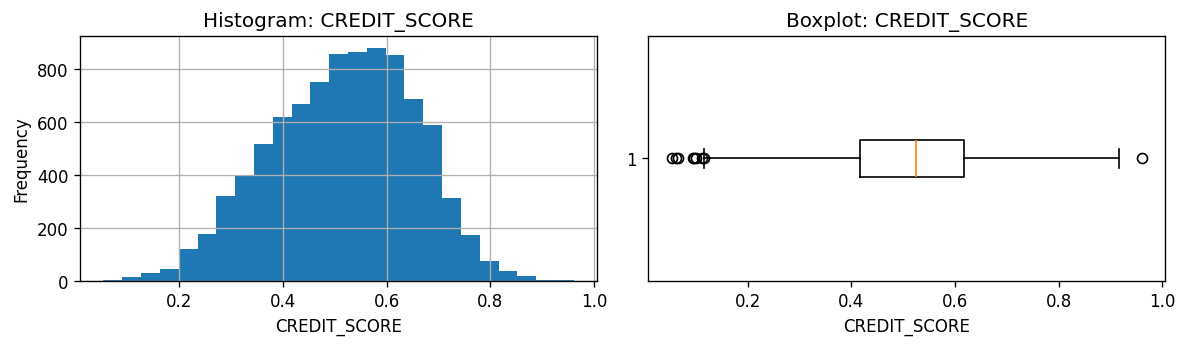

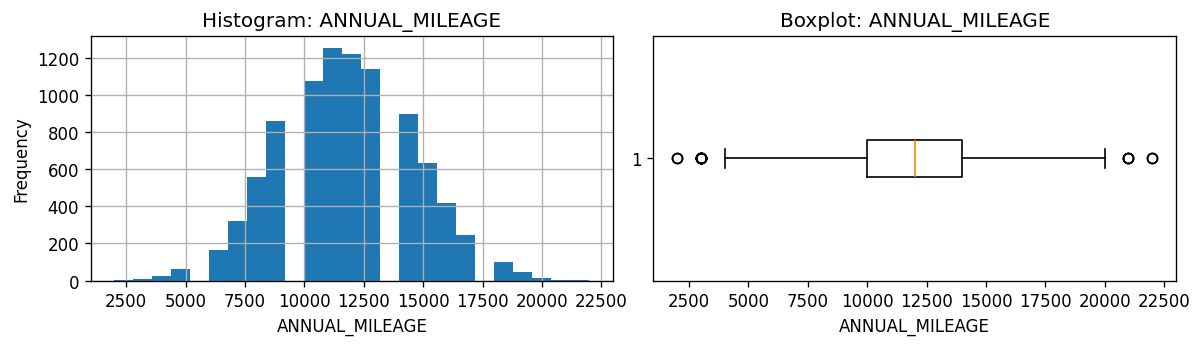

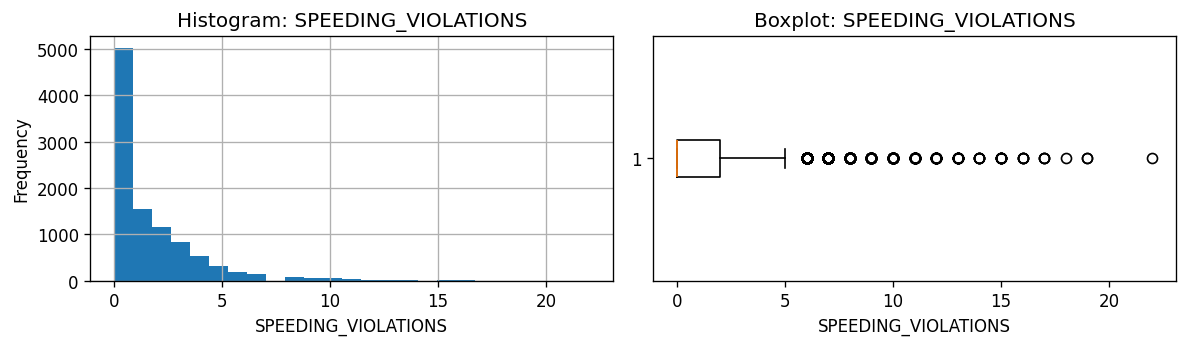

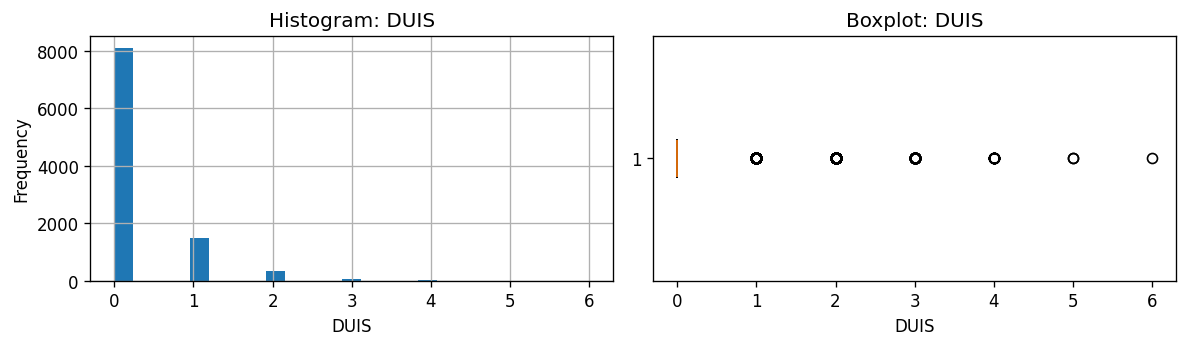

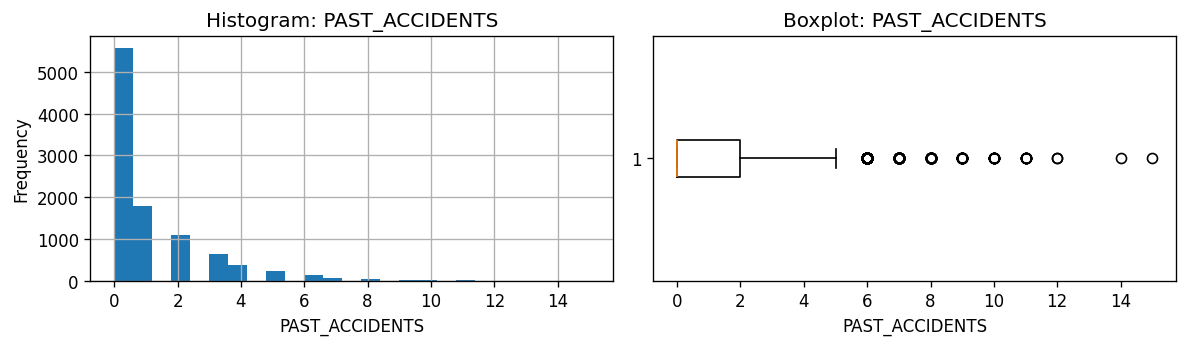

In [18]:
numeric_review_cols = ["CREDIT_SCORE", "ANNUAL_MILEAGE", "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS"]

for col in numeric_review_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    df_raw[col].dropna().hist(bins=25, ax=axes[0])
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    axes[1].boxplot(df_raw[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot: {col}")
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

### Categorical-variable review: category balance

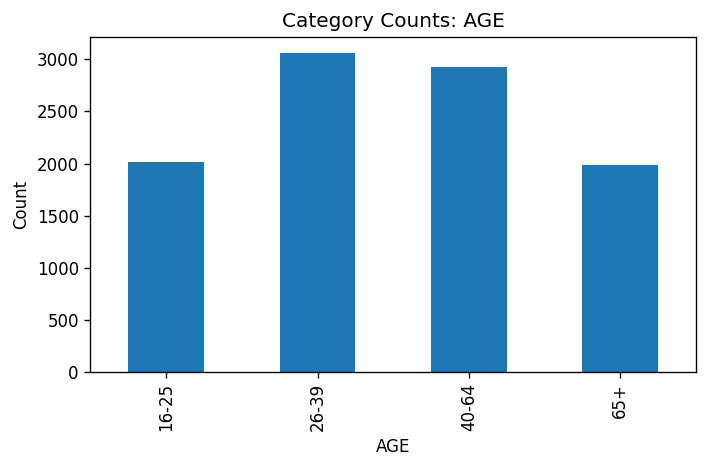

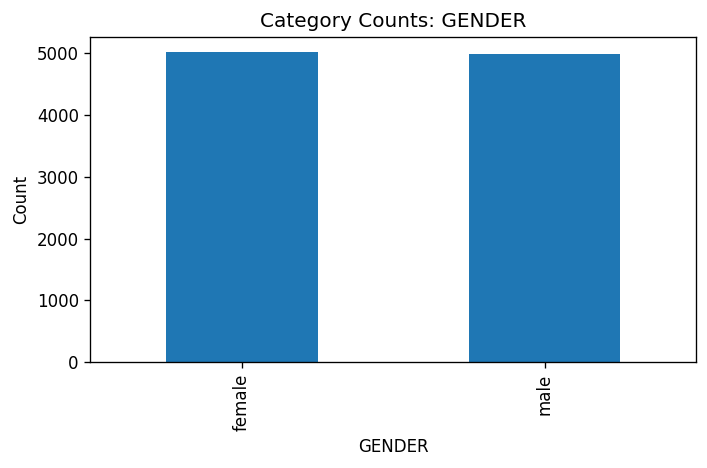

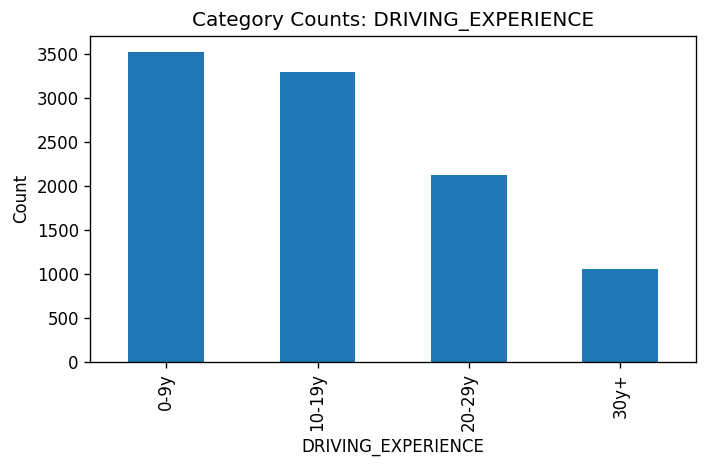

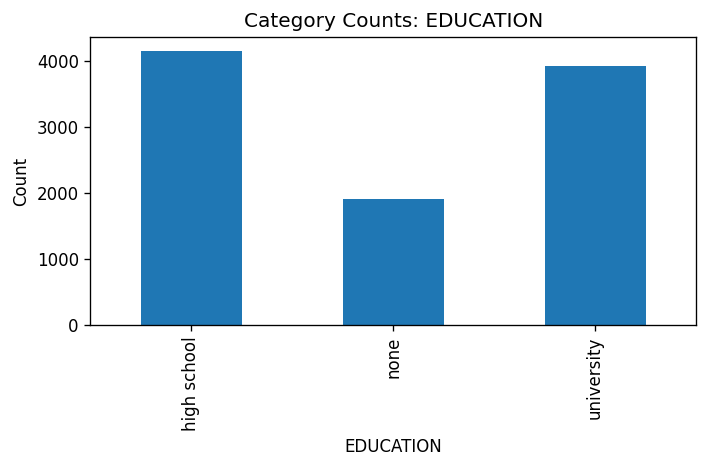

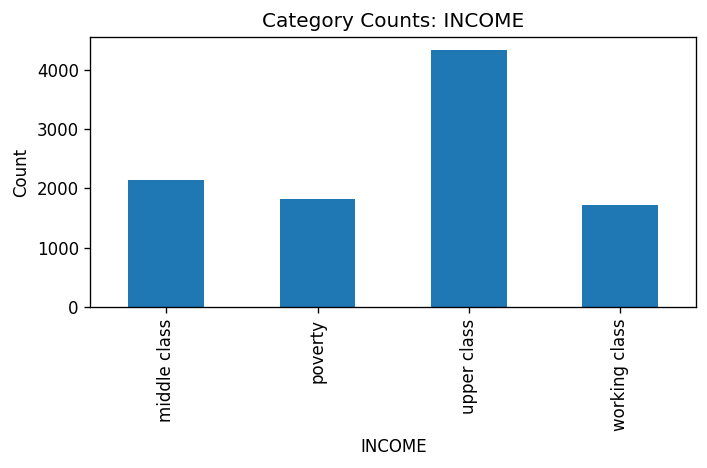

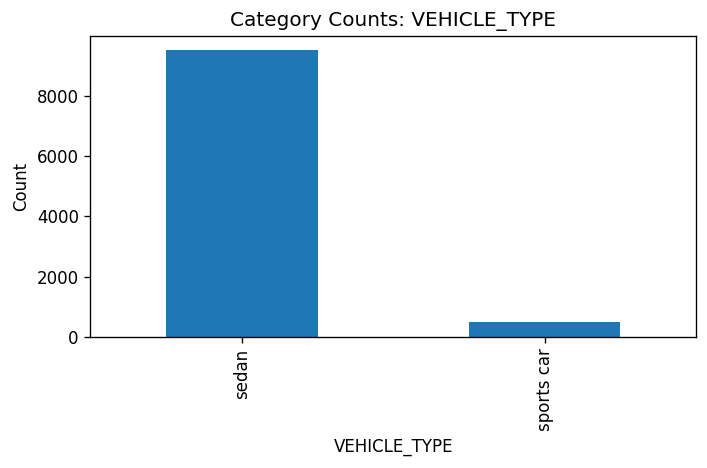

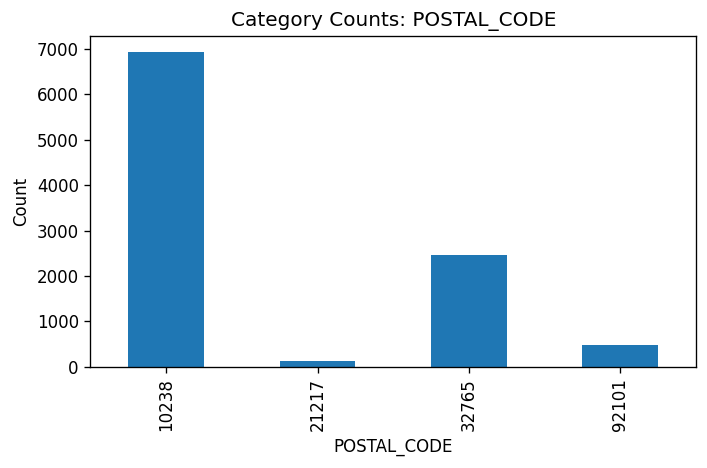

In [19]:
categorical_review_cols = ["AGE", "GENDER", "DRIVING_EXPERIENCE", "EDUCATION", "INCOME", "VEHICLE_TYPE", "POSTAL_CODE"]

for col in categorical_review_cols:
    plot_series = df_raw[col].astype(str).value_counts().sort_index()
    plot_series.plot(kind="bar")
    plt.title(f"Category Counts: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Outlier summary for numeric fields

In [20]:
outlier_rows = []
for col in numeric_review_cols:
    s = df_raw[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((s < lower) | (s > upper)).sum()
    outlier_rows.append({
        "Variable": col,
        "Mean": round(s.mean(), 3),
        "Median": round(s.median(), 3),
        "Std": round(s.std(), 3),
        "Skew": round(s.skew(), 3),
        "IQR_Outliers": int(outliers),
        "Outlier_Pct": round(outliers / len(s) * 100, 2),
        "Min": round(s.min(), 3),
        "Max": round(s.max(), 3)
    })

outlier_summary_df = pd.DataFrame(outlier_rows)
outlier_summary_df

,Variable,Mean,Median,Std,Skew,IQR_Outliers,Outlier_Pct,Min,Max
0,CREDIT_SCORE,0.516,0.525,0.138,-0.226,9,0.10,0.053,0.961
1,ANNUAL_MILEAGE,11697.003,12000.000,2818.435,0.040,17,0.19,2000.000,22000.000
2,SPEEDING_VIOLATIONS,1.483,0.000,2.242,2.365,588,5.88,0.000,22.000
3,DUIS,0.239,0.000,0.555,2.758,1882,18.82,0.000,6.000
4,PAST_ACCIDENTS,1.056,0.000,1.652,2.149,285,2.85,0.000,15.000


### Unscaled-feature review

In [21]:
scale_review_cols = ["CREDIT_SCORE", "ANNUAL_MILEAGE", "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS", "POSTAL_CODE"]

scale_rows = []
for col in scale_review_cols:
    s = df_raw[col].dropna()
    scale_rows.append({
        "Variable": col,
        "dtype": str(df_raw[col].dtype),
        "Min": float(s.min()),
        "Max": float(s.max()),
        "Range": float(s.max() - s.min()),
        "Std": float(s.std())
    })

scale_review_df = pd.DataFrame(scale_rows).sort_values("Range", ascending=False)
scale_review_df

,Variable,dtype,Min,Max,Range,Std
5,POSTAL_CODE,int64,10238.000000,92101.000000,81863.000000,18915.613855
1,ANNUAL_MILEAGE,float64,2000.000000,22000.000000,20000.000000,2818.434528
2,SPEEDING_VIOLATIONS,int64,0.000000,22.000000,22.000000,2.241966
4,PAST_ACCIDENTS,int64,0.000000,15.000000,15.000000,1.652454
3,DUIS,int64,0.000000,6.000000,6.000000,0.554990
0,CREDIT_SCORE,float64,0.053358,0.960819,0.907461,0.137688


## Question 6

In [22]:
df = df_raw.copy()

# ID
# Identifier only, so remove it from the modeling dataset.
df = df.drop(columns=["ID"])

# CREDIT_SCORE
# Missing values present. Median is used because it is robust and keeps the bounded score distribution intact.
df["CREDIT_SCORE"] = df["CREDIT_SCORE"].fillna(df["CREDIT_SCORE"].median())

# POSTAL_CODE
# Convert to string so it is treated as a categorical location field rather than a continuous number.
df["POSTAL_CODE"] = df["POSTAL_CODE"].astype(str)

# ANNUAL_MILEAGE
# Missing values present. Median imputation is used because the variable is discrete by thousands and median is robust.
df["ANNUAL_MILEAGE"] = df["ANNUAL_MILEAGE"].fillna(df["ANNUAL_MILEAGE"].median())


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  object 
 1   GENDER               10000 non-null  object 
 2   DRIVING_EXPERIENCE   10000 non-null  object 
 3   EDUCATION            10000 non-null  object 
 4   INCOME               10000 non-null  object 
 5   CREDIT_SCORE         10000 non-null  float64
 6   VEHICLE_OWNERSHIP    10000 non-null  int64  
 7   MARRIED              10000 non-null  int64  
 8   CHILDREN             10000 non-null  int64  
 9   POSTAL_CODE          10000 non-null  object 
 10  ANNUAL_MILEAGE       10000 non-null  float64
 11  VEHICLE_TYPE         10000 non-null  object 
 12  SPEEDING_VIOLATIONS  10000 non-null  int64  
 13  DUIS                 10000 non-null  int64  
 14  PAST_ACCIDENTS       10000 non-null  int64  
 15  OUTCOME              10000 non-null  

## Question 7




In [23]:
age_experience_overlap = pd.crosstab(df['AGE'], df['DRIVING_EXPERIENCE'])
age_experience_overlap

DRIVING_EXPERIENCE,0-9y,10-19y,20-29y,30y+
AGE,,,,
16-25,2016,0,0,0
26-39,683,2380,0,0
40-64,533,587,1811,0
65+,298,332,308,1052


In [10]:
df_sig = df.copy()
df_sig = df_sig.drop(columns=["AGE"])

X_sig = pd.get_dummies(df_sig.drop(columns=["OUTCOME"]), drop_first=True).astype(float)
y_sig = df_sig["OUTCOME"].astype(float)

X_sig = sm.add_constant(X_sig)
glm_model = sm.GLM(y_sig, X_sig, family=sm.families.Binomial()).fit()

sig_results = pd.DataFrame({
    "Variable": glm_model.params.index,
    "Coefficient": glm_model.params.values,
    "p_value": glm_model.pvalues.values
})

sig_results = sig_results[(sig_results["Variable"] != "const") & (sig_results["p_value"] <= 0.05)].copy()
sig_results = sig_results.sort_values("p_value")
sig_results["Coefficient"] = sig_results["Coefficient"].round(4)
sig_results

,Variable,Coefficient,p_value
2,VEHICLE_OWNERSHIP,-1.7304,3.698728e-143
10,DRIVING_EXPERIENCE_10-19y,-1.9049,1.930314e-114
11,DRIVING_EXPERIENCE_20-29y,-3.8815,5.139142e-107
9,GENDER_male,0.9901,1.354983e-52
19,POSTAL_CODE_32765,1.1138,1.664523e-44
12,DRIVING_EXPERIENCE_30y+,-4.7311,6.996295e-38
20,POSTAL_CODE_92101,1.3452,4.209424e-22
5,ANNUAL_MILEAGE,0.0001,1.613393e-12
3,MARRIED,-0.3420,1.217949e-06
16,INCOME_upper class,-0.3525,1.225507e-04


## Questions 8,9

In [11]:
X = df_sig.drop(columns=["OUTCOME"])
y = df_sig["OUTCOME"]

categorical_cols = ["GENDER", "DRIVING_EXPERIENCE", "EDUCATION", "INCOME", "POSTAL_CODE", "VEHICLE_TYPE"]
numeric_cols = ["CREDIT_SCORE", "VEHICLE_OWNERSHIP", "MARRIED", "CHILDREN", "ANNUAL_MILEAGE", "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic regression: scale numeric features
log_preprocessor = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

log_model = Pipeline([
    ("prep", log_preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Tree ensembles: no scaling required
tree_preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

rf_model = Pipeline([
    ("prep", tree_preprocessor),
    ("clf", RandomForestClassifier(n_estimators=1000, random_state=42))
])

gb_model = Pipeline([
    ("prep", tree_preprocessor),
    ("clf", GradientBoostingClassifier(n_estimators=1000, random_state=42))
])

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)
pred_rf = rf_model.predict(X_test)
pred_gb = gb_model.predict(X_test)

In [12]:
metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (1000 trees)", "Gradient Boosting (1000 stages)"],
    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb)
    ],
    "Precision": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_gb)
    ],
    "Recall": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_gb)
    ],
    "F1": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_gb)
    ]
}).round(4)

metrics_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8320,0.7454,0.7049,0.7246
1,Random Forest (1000 trees),0.8005,0.6919,0.6555,0.6732
2,Gradient Boosting (1000 stages),0.8170,0.7122,0.6986,0.7053


In [13]:
cm_log = confusion_matrix(y_test, pred_log)
cm_rf = confusion_matrix(y_test, pred_rf)
cm_gb = confusion_matrix(y_test, pred_gb)

cm_df = pd.DataFrame([
    ["Logistic Regression", cm_log[0,0], cm_log[0,1], cm_log[1,0], cm_log[1,1]],
    ["Random Forest", cm_rf[0,0], cm_rf[0,1], cm_rf[1,0], cm_rf[1,1]],
    ["Gradient Boosting", cm_gb[0,0], cm_gb[0,1], cm_gb[1,0], cm_gb[1,1]]
], columns=["Model", "TN", "FP", "FN", "TP"])

cm_df

,Model,TN,FP,FN,TP
0,Logistic Regression,1222,151,185,442
1,Random Forest,1190,183,216,411
2,Gradient Boosting,1196,177,189,438


## Question 10

In [14]:
# Logistic coefficients (for interpretation)
log_ohe = log_model.named_steps["prep"].named_transformers_["cat"]
log_feature_names = numeric_cols + list(log_ohe.get_feature_names_out(categorical_cols))
log_coef = pd.Series(log_model.named_steps["clf"].coef_[0], index=log_feature_names).sort_values(key=lambda s: s.abs(), ascending=False)

# Tree-based feature importance
tree_ohe = rf_model.named_steps["prep"].named_transformers_["cat"]
tree_feature_names = numeric_cols + list(tree_ohe.get_feature_names_out(categorical_cols))

rf_importance = pd.Series(rf_model.named_steps["clf"].feature_importances_, index=tree_feature_names).sort_values(ascending=False)
gb_importance = pd.Series(gb_model.named_steps["clf"].feature_importances_, index=tree_feature_names).sort_values(ascending=False)

print("Top logistic coefficients by absolute value")
display(log_coef.head(10).to_frame("Coefficient"))

print("Top Random Forest feature importances")
display(rf_importance.head(10).to_frame("Importance"))

print("Top Gradient Boosting feature importances")
display(gb_importance.head(10).to_frame("Importance"))

Top logistic coefficients by absolute value


,Coefficient
POSTAL_CODE_21217,6.285613
DRIVING_EXPERIENCE_30y+,-3.867858
DRIVING_EXPERIENCE_20-29y,-3.625830
DRIVING_EXPERIENCE_10-19y,-1.764248
POSTAL_CODE_92101,1.124390
POSTAL_CODE_32765,1.075301
GENDER_male,0.967857
VEHICLE_OWNERSHIP,-0.781759
INCOME_poverty,0.400811
INCOME_upper class,-0.335493


Top Random Forest feature importances


,Importance
CREDIT_SCORE,0.226287
ANNUAL_MILEAGE,0.115795
VEHICLE_OWNERSHIP,0.093359
SPEEDING_VIOLATIONS,0.089993
PAST_ACCIDENTS,0.080659
DRIVING_EXPERIENCE_10-19y,0.048354
INCOME_poverty,0.035695
GENDER_male,0.034809
INCOME_upper class,0.034679
DRIVING_EXPERIENCE_20-29y,0.033997


Top Gradient Boosting feature importances


,Importance
SPEEDING_VIOLATIONS,0.177058
VEHICLE_OWNERSHIP,0.172175
CREDIT_SCORE,0.154634
DRIVING_EXPERIENCE_10-19y,0.103629
PAST_ACCIDENTS,0.094879
POSTAL_CODE_21217,0.047671
GENDER_male,0.041691
INCOME_upper class,0.038111
DRIVING_EXPERIENCE_20-29y,0.034032
INCOME_poverty,0.032410
